# Single Index Model

Sharpe's **Single Index Model (SIM)** decomposes each asset's return into a part driven by the market and a part specific to the asset:

$$ R_i = \alpha_i + \beta_i R_m + \epsilon_i, $$

with the corresponding variance decomposition

$$ \underbrace{\sigma_i^2}_{\text{total}} = \underbrace{\beta_i^2 \sigma_m^2}_{\text{systematic}} + \underbrace{\sigma_{\epsilon_i}^2}_{\text{firm-specific}}. $$

Systematic risk is undiversifiable; firm-specific risk vanishes in a sufficiently large, well-spread portfolio.

This notebook walks through:

1. Loading prices and computing returns.
2. EDA on the market proxy (S&P 500) — the most important single column for the SIM.
3. A scatter / regression plot for one ticker, building intuition for what $\alpha$, $\beta$, and $\epsilon$ are geometrically.
4. Fitting the SIM on the whole universe with `SingleIndexModel`.
5. Visualising the cross-sectional distribution of betas, $R^2$, and the systematic / firm-specific decomposition.

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from portfolio import config
from portfolio.data import DataIngestion
from portfolio.models import SingleIndexModel

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ingestion = DataIngestion()
prices = ingestion.get_all_prices()
returns = DataIngestion.compute_returns(prices)
market = returns[config.sp500_ticker]

[                       0%                       ]

[*                      2%                       ]  2 of 122 completed

[*                      2%                       ]  3 of 122 completed

[*                      3%                       ]  4 of 122 completed

[*                      3%                       ]  4 of 122 completed

...

[**********************97%********************** ]  118 of 122 completed

[**********************98%********************** ]  119 of 122 completed

[**********************98%********************** ]  120 of 122 completed

[**********************99%***********************]  121 of 122 completed

[*********************100%***********************]  122 of 122 completed

## 2. EDA — the market series

The SIM treats the market as the single common factor driving every asset, so the market series deserves more scrutiny than the others. The four diagnostics below — descriptive stats, rolling 60-day volatility, autocorrelation, and the histogram with a normal overlay — are a sensible baseline.

In [2]:
market.describe()

count    16.000000
mean     -0.000075
std       0.012179
min      -0.017406
25%      -0.006361
50%       0.000940
75%       0.005856
max       0.029131
Name: ^GSPC, dtype: float64

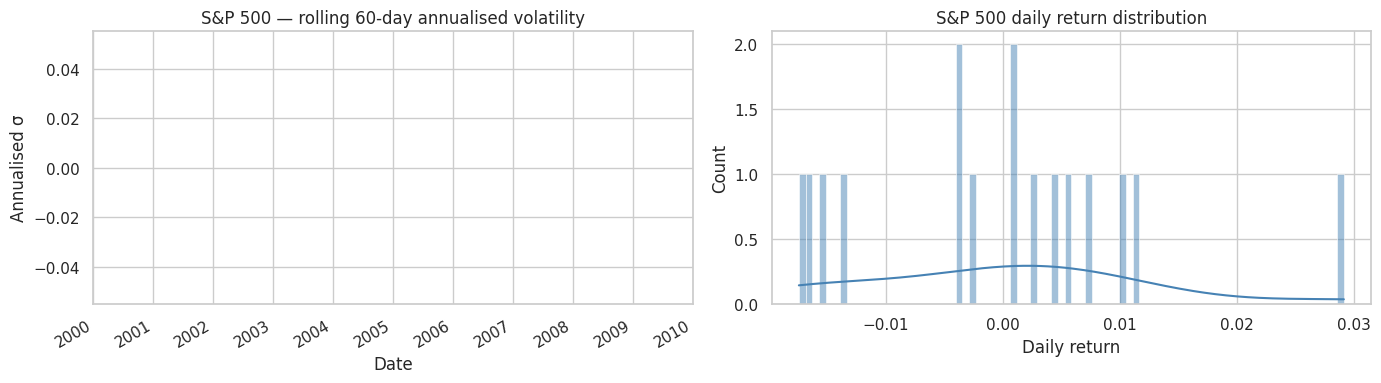

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rolling_vol = market.rolling(window=60).std() * np.sqrt(252)
rolling_vol.plot(ax=axes[0], color="steelblue")
axes[0].set_title("S&P 500 — rolling 60-day annualised volatility")
axes[0].set_ylabel("Annualised σ")
axes[0].set_xlabel("Date")

sns.histplot(market, bins=80, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("S&P 500 daily return distribution")
axes[1].set_xlabel("Daily return")
fig.tight_layout()
plt.show()

## 3. Visual intuition — one asset against the market

Plotting one asset's returns against the market's returns and fitting a line gives visual meaning to the regression coefficients. The slope is $\beta$; the intercept is $\alpha$; the vertical distance from each point to the line is the residual $\epsilon$.

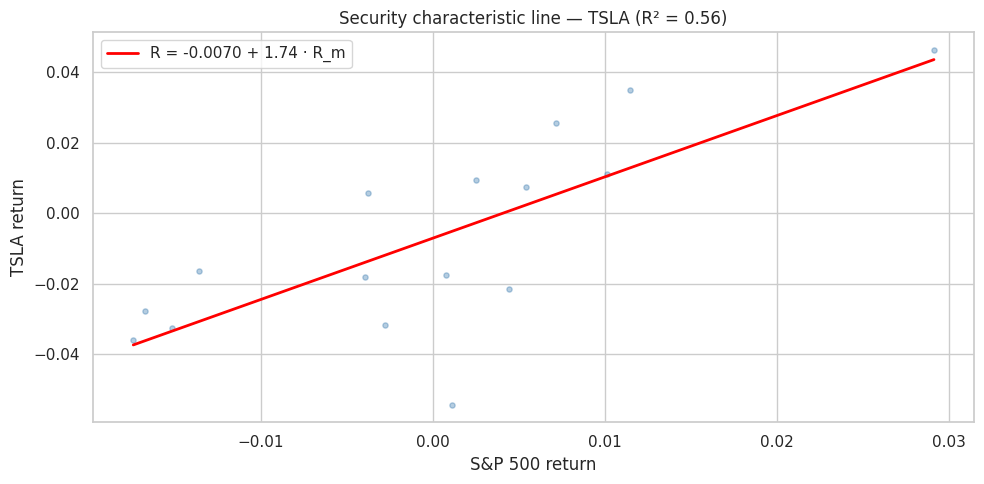

In [4]:
ticker = "TSLA"
asset = returns[ticker]

x_with_const = sm.add_constant(market)
fit = sm.OLS(asset, x_with_const).fit()
alpha, beta = float(fit.params.iloc[0]), float(fit.params.iloc[1])

fig, ax = plt.subplots()
ax.scatter(market, asset, alpha=0.4, s=14, color="steelblue")
x_line = np.linspace(market.min(), market.max(), 50)
ax.plot(x_line, alpha + beta * x_line, color="red", linewidth=2,
        label=f"R = {alpha:+.4f} + {beta:.2f} · R_m")
ax.set_xlabel("S&P 500 return")
ax.set_ylabel(f"{ticker} return")
ax.set_title(f"Security characteristic line — {ticker} (R² = {fit.rsquared:.2f})")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Fitting the SIM across the universe

`SingleIndexModel.get_models` runs the regression for every ticker in the supplied list against a market proxy column. The fitted model objects are cached on `sim.results`.

In [5]:
sim = SingleIndexModel()
sim.get_models(
    tickers=config.all_tickers,
    market_ticker=config.sp500_ticker,
    returns=returns,
)

alphas = pd.Series(sim.get_alphas())
betas = pd.Series(sim.get_betas())
systematic = pd.Series(sim.get_systematic_risks())
firm_specific = pd.Series(sim.get_firm_specific_risks())
total = pd.Series(sim.get_total_risks())
r_squared = pd.Series({t: m.rsquared for t, m in sim.results.items()})

summary = pd.DataFrame({
    "alpha": alphas,
    "beta": betas,
    "R²": r_squared,
    "systematic": systematic,
    "firm_specific": firm_specific,
})
summary.head(10)

,alpha,beta,R²,systematic,firm_specific
INTC,0.010278,2.353935,0.381629,8.218441e-04,0.001332
HOLX,0.000738,0.003473,0.000613,1.789051e-09,0.000003
NVDA,-0.000369,1.773401,0.881179,4.664601e-04,0.000063
NOK,0.004954,1.351795,0.331058,2.710331e-04,0.000548
PLTR,0.000335,2.281643,0.677851,7.721404e-04,0.000367
PLUG,0.011250,2.185973,0.294013,7.087454e-04,0.001702
NIO,0.004027,3.077570,0.746874,1.404806e-03,0.000476
CRWV,0.004791,3.199944,0.491091,1.518748e-03,0.001574
EOSE,-0.013410,3.022621,0.444782,1.355089e-03,0.001692
TSLA,-0.007023,1.739694,0.564528,4.488966e-04,0.000346


### Sanity check — regressing the market on itself

By construction, this must give $\alpha = 0$, $\beta = 1$, and $R^2 = 1$ — and it does, within numerical precision.

In [6]:
summary.loc[config.sp500_ticker]

alpha            4.336809e-19
beta             1.000000e+00
R²               1.000000e+00
systematic       1.483203e-04
firm_specific    3.017372e-35
Name: ^GSPC, dtype: float64

## 5. Cross-sectional view

The two distributions below summarise the cross-section. Most betas cluster around 1, with a long right tail of high-beta tech and crypto names. $R^2$ ranges from near-zero (assets that move independently of the S&P 500) up to nearly 1 (S&P 500 trackers like QQQ).

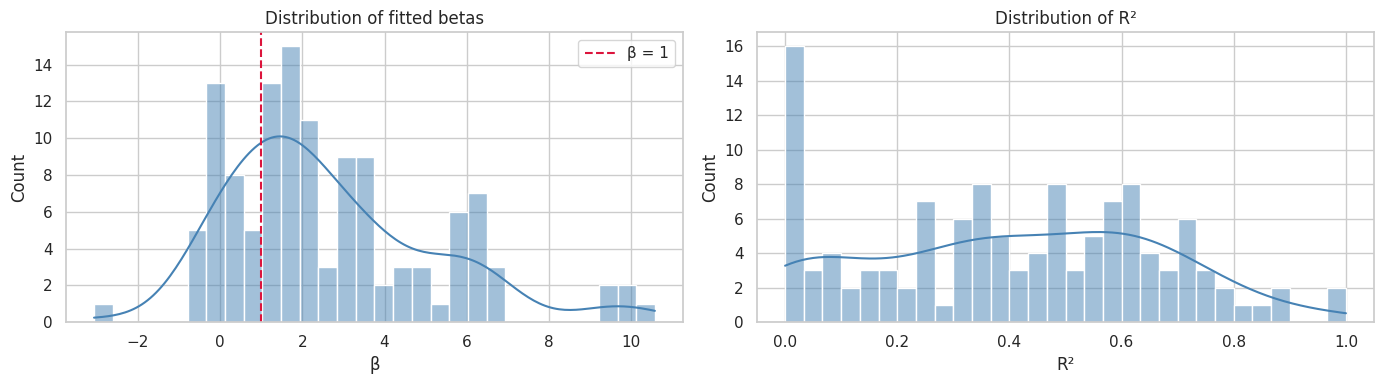

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(betas, bins=30, kde=True, color="steelblue", ax=axes[0])
axes[0].axvline(1.0, color="crimson", linestyle="--", label="β = 1")
axes[0].set_title("Distribution of fitted betas")
axes[0].set_xlabel("β")
axes[0].legend()

sns.histplot(r_squared, bins=30, kde=True, color="steelblue", ax=axes[1])
axes[1].set_title("Distribution of R²")
axes[1].set_xlabel("R²")

fig.tight_layout()
plt.show()

### Risk decomposition

Stacking systematic and firm-specific risk side by side makes the diversifiable component visible at a glance. Limit the plot to the 30 largest-systematic-risk tickers to keep it readable.

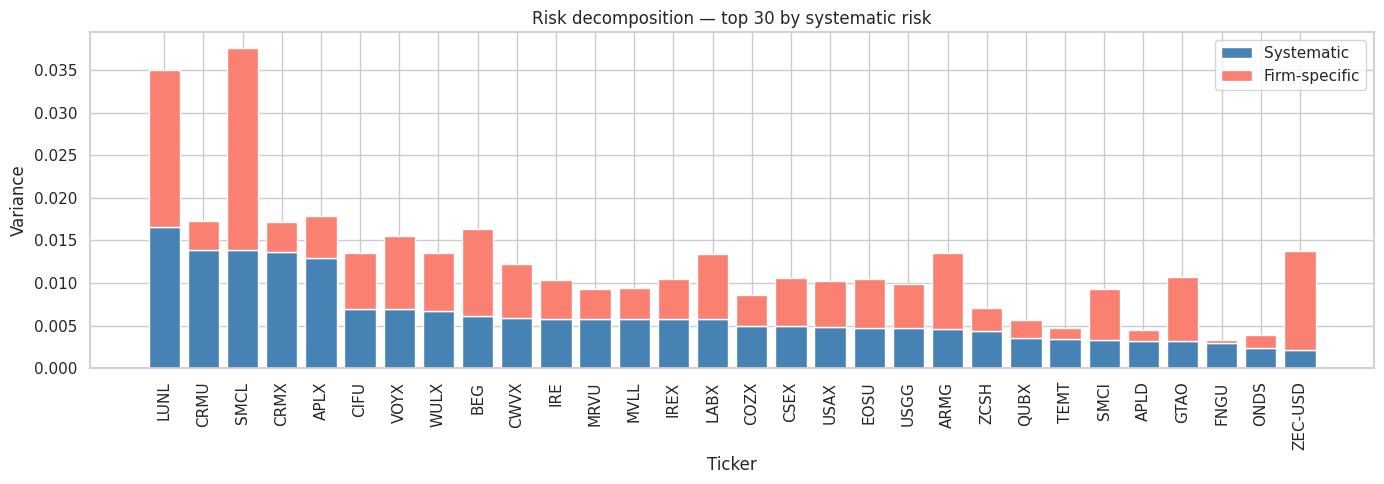

In [8]:
decomposition = (
    pd.DataFrame({"systematic": systematic, "firm_specific": firm_specific})
    .sort_values("systematic", ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(decomposition.index, decomposition["systematic"],
       label="Systematic", color="steelblue")
ax.bar(decomposition.index, decomposition["firm_specific"],
       bottom=decomposition["systematic"],
       label="Firm-specific", color="salmon")
ax.set_title("Risk decomposition — top 30 by systematic risk")
ax.set_xlabel("Ticker")
ax.set_ylabel("Variance")
ax.tick_params(axis="x", rotation=90)
ax.legend()
fig.tight_layout()
plt.show()